<a href="https://colab.research.google.com/github/SumukhaSrivatsa-BSC/BSC_AI_Training/blob/main/14-07-2026/14_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(np.float64(-0.5), np.float64(5815.5), np.float64(3271.5), np.float64(-0.5))

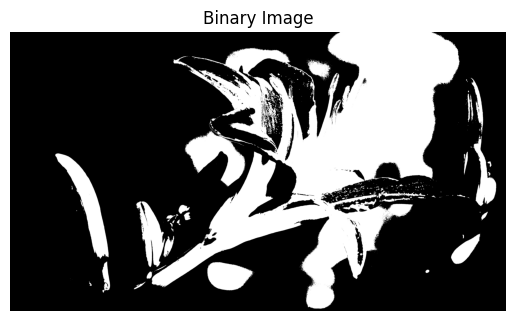

In [ ]:
import cv2
import matplotlib.pyplot as plt


image = cv2.imread('/content/flower_image') # Placeholder, please define your image


#Thresholding
#Convert the original colour image (BGR) into a grayscale image
#
# Thresholding works on grayscale images because each pixel has only one intensity value (0-255)
gray=cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Apply Binary Thresholding
# Syntax:
# cv2.threshold(source_image, threshold_value, max_value, threshold_type)
#
# Arguments for cv2.threshold:
# gray: Input grayscale image
# 127: Threshold value (T). Every pixel is compared with this value
# 255: Maximum value assigned to pixels exceeding the threshold
# cv2.THRESH_BINARY: Type of thresholding to apply (binary thresholding)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Display the binary image using Matplotlib
# cmap="gray" displays the image in grayscale
plt.imshow(binary, cmap="gray")

# Add a title above the image
plt.title("Binary Image")

# Hide x-axis and y-axis
plt.axis("off")

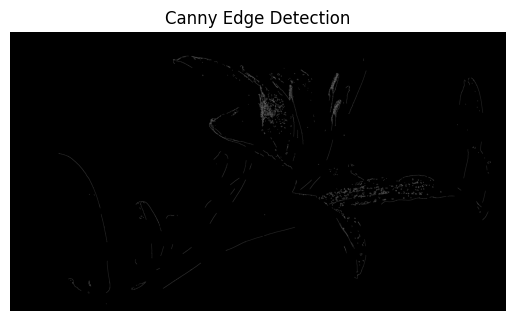

In [ ]:
#Canny Edge Detection
# Convert the original colour image (BGR) into a grayscale image
# Canny Edge Detection works on grayscale images
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply the Canny Edge Detection algorithm
# Syntax:
# cv2.Canny(image, lower_threshold, upper_threshold)
# Input grayscale image
# Lower Threshold: 100
# Upper Threshold: 200
edges = cv2.Canny(gray, 100, 200)

# Display the detected edges
plt.imshow(edges, cmap="gray")

# Add a title
plt.title("Canny Edge Detection")

# Hide x-axis and y-axis
plt.axis("off")

# Display the final edge image
plt.show()

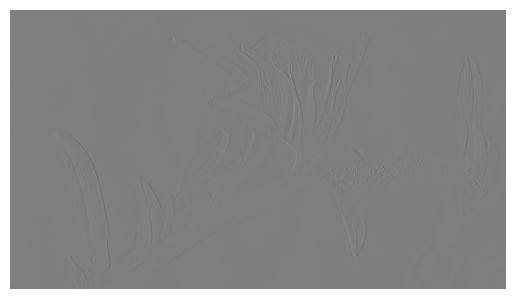

In [ ]:
#Sobel Edge Detection

#Sobel X(Horizontal)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 1,0 = detect horizontal edges
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)

plt.imshow(sobel_x, cmap="gray")
plt.axis("off")
plt.show()

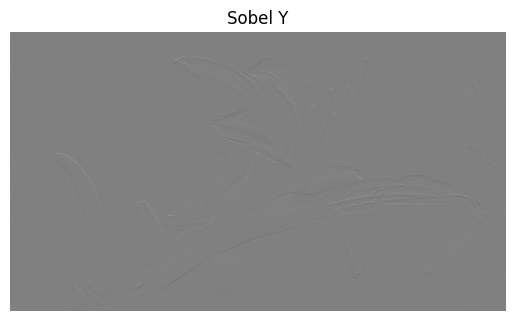

In [ ]:
#Sobel Y(Vertical)
# 0,1 = detect vertical edges
sobel_y = cv2.Sobel(
gray, cv2.CV_64F,
0, 1, ksize=3)

plt.imshow(sobel_y, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")
plt.show()

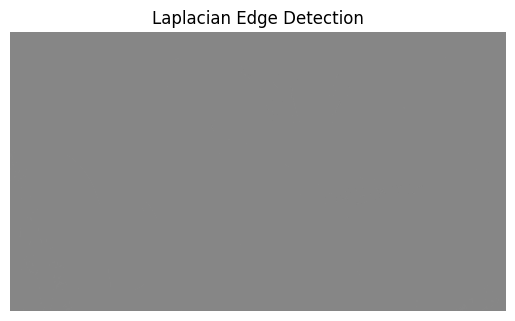

In [ ]:
#Laplacian Edge Detection
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

laplacian = cv2.Laplacian(
gray, cv2.CV_64F)

plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian Edge Detection")
plt.axis("off")
plt.show()

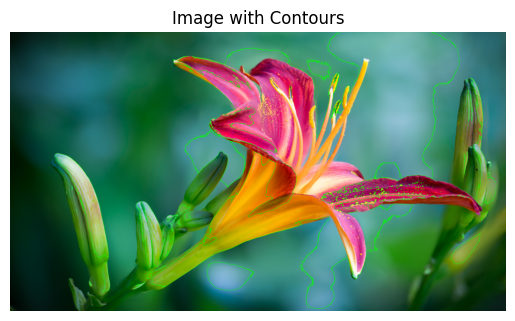

In [ ]:
#Contours
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Find the outlines in the binary image
contours, hierarchy = cv2.findContours(
binary,
cv2.RETR_EXTERNAL,
cv2.CHAIN_APPROX_SIMPLE)

# outer contours only
# compress the points

# Draw all contours found, in green
contour_img = image.copy()
cv2.drawContours(contour_img, contours, -1, (0,255,0), 2)

# Display the image with contours
plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.title("Image with Contours")
plt.axis("off")
plt.show()

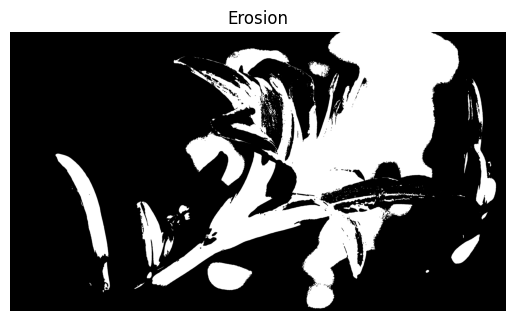

In [ ]:
import numpy as np

#Erosion
kernel = np.ones((5,5), np.uint8)

# Removes pixels from
# object edges
eroded = cv2.erode(
binary, kernel,
iterations=1)

plt.imshow(eroded, cmap="gray")
plt.title("Erosion")
plt.axis("off")
plt.show()

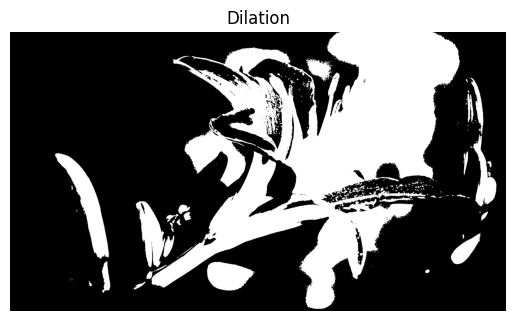

In [ ]:
#Dilation
# Adds pixels to
# object edges
dilated = cv2.dilate(
binary, kernel,
iterations=1)

plt.imshow(dilated, cmap="gray")
plt.title("Dilation")
plt.axis("off")
plt.show()

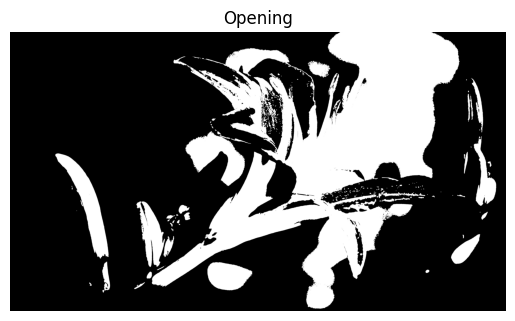

In [ ]:
#Opening=Erode then dilate
opening = cv2.morphologyEx(
binary,
cv2.MORPH_OPEN,
kernel)

plt.imshow(opening, cmap="gray")
plt.title("Opening")
plt.axis("off")
plt.show()

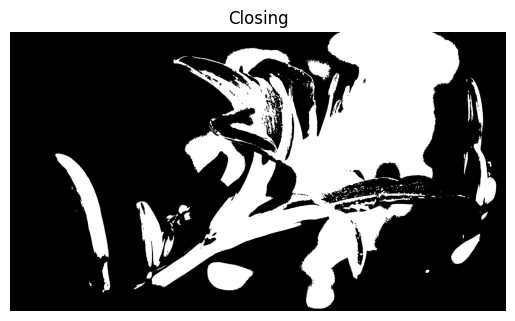

In [ ]:
closing = cv2.morphologyEx(
binary,
cv2.MORPH_CLOSE,
kernel)

plt.imshow(closing, cmap="gray")
plt.title("Closing")
plt.axis("off")
plt.show()

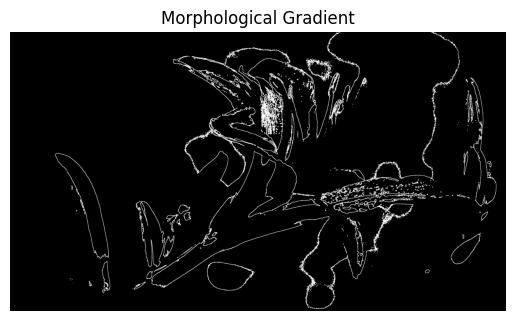

In [ ]:
#Morphological Gradient
gradient = cv2.morphologyEx(
binary,
cv2.MORPH_GRADIENT,
kernel)

# Note: Morphological Gradient is often defined as (dilation - erosion).
# The line '+ dilation - eroaion' was a syntax error.

plt.imshow(gradient, cmap="gray")
plt.title("Morphological Gradient")
plt.axis("off")
plt.show()

In [ ]:
#Mini Project-Image processing Toolkit

#One pipeline, one uploaded image: resize -> grayscale -> blur > edges -> annotate > display all three results together.

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Make sure to import cv2 and matplotlib.pyplot if not already done in earlier cells
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread(filename)

# Check if image was loaded correctly
if image is None:
    print(f"Error: Could not load image from {filename}. Please ensure the file exists and the path is correct.")
else:
    image = cv2.resize(image, (400,400))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    edges = cv2.Canny(blur, 100, 200)

    output = image.copy()
    cv2.rectangle(
        output, (50,50), (200,200),
        (0,255,0), 3
    )



Saving flower_image to flower_image (1)


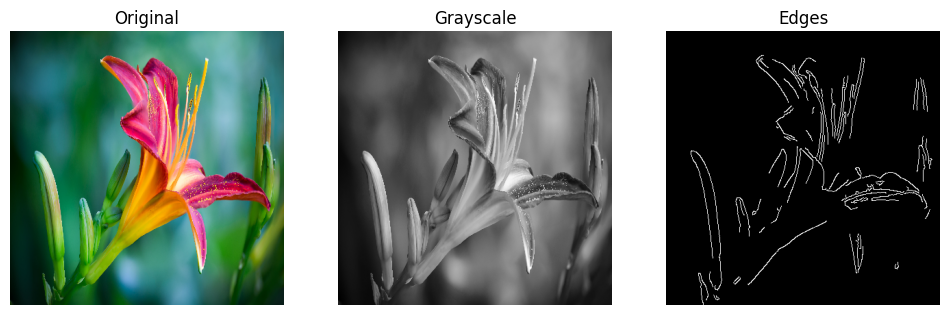

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(
image, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.show()

In [ ]:
#NLP

In [ ]:
import pandas as pd

data = {
"Review": [
"Amazihg phone", "Worst battery",
"Excellent camera", "Bad display",
"Very good performance", "Poor quality"
],
"Sentiment": [
"Positive", "Negative", "Positive",
"Negative", "Positive", "Negative"
]

}

df = pd.DataFrame (data)
df.head()


,Review,Sentiment
0,Amazihg phone,Positive
1,Worst battery,Negative
2,Excellent camera,Positive
3,Bad display,Negative
4,Very good performance,Positive


In [ ]:
df.shape

(6, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     6 non-null      object
 1   Sentiment  6 non-null      object
dtypes: object(2)
memory usage: 228.0+ bytes


In [ ]:
df.describe()

,Review,Sentiment
count,6,6
unique,6,2
top,Amazihg phone,Positive
freq,1,3


In [ ]:
df.tail()

,Review,Sentiment
1,Worst battery,Negative
2,Excellent camera,Positive
3,Bad display,Negative
4,Very good performance,Positive
5,Poor quality,Negative


In [ ]:
df["Sentiment"].value_counts()

,count
Sentiment,
Positive,3
Negative,3


In [ ]:
df["Review"]=df["Review"].str.lower()
df

,Review,Sentiment
0,amazihg phone,Positive
1,worst battery,Negative
2,excellent camera,Positive
3,bad display,Negative
4,very good performance,Positive
5,poor quality,Negative


In [ ]:
df['Length']=df['Review'].apply(len)
df

,Review,Sentiment,Length
0,amazihg phone,Positive,13
1,worst battery,Negative,13
2,excellent camera,Positive,16
3,bad display,Negative,11
4,very good performance,Positive,21
5,poor quality,Negative,12


In [ ]:
for review in df['Review']:
    print(review)

amazihg phone
worst battery
excellent camera
bad display
very good performance
poor quality


In [ ]:
df['Review'].str.contains("phone")

,Review
0,True
1,False
2,False
3,False
4,False
5,False


In [ ]:
positive_reviews=df[df['Sentiment']=='Positive']
positive_reviews

,Review,Sentiment,Length
0,amazihg phone,Positive,13
2,excellent camera,Positive,16
4,very good performance,Positive,21


In [ ]:
import string
# The fast, 'industry standard' way using translate()
sentence = "Amazing !!! Phone."

# Build a translation table: map every punctuation
# character to nothing (delete it)
table = str.maketrans('', '', string.punctuation)

# Apply the table to the sentence
clean = sentence.translate (table)

print (clean)

Amazing  Phone


In [ ]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt') # one time model download
nltk.download('punkt_tab') # Download the specific resource for Punkt tokenizer

text = "I love NLP. Python is amazing."

# Break the paragraph into SENTENCES
print (sent_tokenize (text))

sentence = "I love learning Natural Language Procesaing."

# Break one sentence into WORDS
print (word_tokenize (sentence))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['I love NLP.', 'Python is amazing.']
['I', 'love', 'learning', 'Natural', 'Language', 'Procesaing', '.']


In [ ]:
data = {
    "Text": [
        "I LOVE this Phone!!! 😍",
        "Worst battery backup!!!",
        "Visit https://abc.com",
        "<h1>Excellent Camera</h1>",
        "Price is 50000 Rupees",
        "Amazing Performance!!!"
    ]
}

In [ ]:
!pip install emoji
import pandas as pd
import emoji

# Create DataFrame
df_emoji = pd.DataFrame(data)

# Function to remove emojis
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

# Apply the function to the 'Text' column
df_emoji['Text_No_Emojis'] = df_emoji['Text'].apply(remove_emojis)

print(df_emoji)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.6 MB/s eta 0:00:00
                        Text             Text_No_Emojis
0     I LOVE this Phone!!! 😍      I LOVE this Phone!!! 
1    Worst battery backup!!!    Worst battery backup!!!
2      Visit https://abc.com      Visit https://abc.com
3  <h1>Excellent Camera</h1>  <h1>Excellent Camera</h1>
4      Price is 50000 Rupees      Price is 50000 Rupees
5     Amazing Performance!!!     Amazing Performance!!!


In [ ]:
df_from_data = pd.DataFrame(data)
df_from_data.head()

,Text
0,I LOVE this Phone!!! 😍
1,Worst battery backup!!!
2,Visit https://abc.com
3,<h1>Excellent Camera</h1>
4,Price is 50000 Rupees


In [ ]:
df_from_data['no_emoji_text'] = df_from_data['Text'].apply(remove_emojis)
df_from_data

,Text,no_emoji_text
0,I LOVE this Phone!!! 😍,I LOVE this Phone!!!
1,Worst battery backup!!!,Worst battery backup!!!
2,Visit https://abc.com,Visit https://abc.com
3,<h1>Excellent Camera</h1>,<h1>Excellent Camera</h1>
4,Price is 50000 Rupees,Price is 50000 Rupees
5,Amazing Performance!!!,Amazing Performance!!!


In [ ]:
df_from_data['tokenized_no_emoji_text'] = df_from_data['no_emoji_text'].apply(nltk.word_tokenize)
df_from_data

,Text,no_emoji_text,tokenized_no_emoji_text
0,I LOVE this Phone!!! 😍,I LOVE this Phone!!!,"[I, LOVE, this, Phone, !, !, !]"
1,Worst battery backup!!!,Worst battery backup!!!,"[Worst, battery, backup, !, !, !]"
2,Visit https://abc.com,Visit https://abc.com,"[Visit, https, :, //abc.com]"
3,<h1>Excellent Camera</h1>,<h1>Excellent Camera</h1>,"[<, h1, >, Excellent, Camera, <, /h1, >]"
4,Price is 50000 Rupees,Price is 50000 Rupees,"[Price, is, 50000, Rupees]"
5,Amazing Performance!!!,Amazing Performance!!!,"[Amazing, Performance, !, !, !]"


In [ ]:
#Stopwords
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')

sentence = "The phone is very good"
stop_words = set (stopwords.words('english'))
tokens = word_tokenize (sentence)

# Keep a word ONLY if it is NOT a stopword
filtered = [w for w in tokens if w.lower() not in stop_words]
print (filtered)

['phone', 'good']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from nltk.stem import PorterStemmer
stemmer=PorterStemmer()
words = ['playing', 'played', 'studying', 'running']

for word in words:
  print (word, '->', stemmer.stem (word) )

playing -> play
played -> play
studying -> studi
running -> run


In [ ]:
# running

from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer ()

print (lemmatizer.lemmatize ('better', pos='a'))

# Without a POS tag, NLTK assumes every word is a NOUN
print (lemmatizer.lemmatize ('running'))

# Telling it the Part-Of-Speech (POS) fixes this:
# f pos='v' means a verb, pos='a' means an adjective
print (lemmatizer.lemmatize('running', pos='v')) # run
# good

[nltk_data] Downloading package wordnet to /root/nltk_data...


good
running
run


In [ ]:
#Complete text preprocessing Pipeline
import re, string, nltk, emoji
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt'); nltk.download('stopwords')

# Input text for preprocessing
text = "I LOVE this Phone !!!😍 Visit https://google.com"

# 1. lowercase
text = text.lower()

# 2. remove URLs
text = re.sub(r'https?:\S+|www\.\S+', '', text)

# 3. remove emojis
text = emoji.replace_emoji(text, replace='')

# 4. remove punctuation
text = text.translate(str.maketrans('', '', string.punctuation))

# 5. remove numbers
text = re.sub(r'\d+', '', text)

# 6. remove extra spaces (replaces multiple spaces with a single space)
text = ' '.join(text.split())

# 7. tokenize
tokens = word_tokenize(text)

# 8. remove stopwords
stop_words = set(stopwords.words('english'))
tokens = [w for w in tokens if w not in stop_words]

print(tokens)


['love', 'phone', 'visit']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
!pip install -q nltk spacy pandas

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("wordnet")
nltk.download("omw-1.4")

!python -m spacy download en_core_web_sm

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk import pos_tag

data = {"Sentence": [
    "I love NLP.",
    "Python is amazing.",
    "Students are learning AI."
]}
df = pd.DataFrame(data)

df["Tokens"] = df["Sentence"].apply(word_tokenize)
df["POS_Tags"] = df["Tokens"].apply(pos_tag)

In [ ]:
df

,Sentence,Tokens,POS_Tags
0,I love NLP.,"[I, love, NLP, .]","[(I, PRP), (love, VBP), (NLP, NNP), (., .)]"
1,Python is amazing.,"[Python, is, amazing, .]","[(Python, NNP), (is, VBZ), (amazing, JJ), (., .)]"
2,Students are learning AI.,"[Students, are, learning, AI, .]","[(Students, NNS), (are, VBP), (learning, VBG),..."


In [ ]:
#Chunking/sparsing
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.chunk import RegexpParser

sentence = "The intelligent student won the competition."
tokens = word_tokenize(sentence)
tags = pos_tag(tokens)

grammar = "NP: {<DT>?<JJ>*<NN>}" # Corrected grammar: <HN> to <NN>
chunk_parser = RegexpParser(grammar)
result = chunk_parser.parse(tags)
print(result)

(S
  (NP The/DT intelligent/JJ student/NN)
  won/VBD
  (NP the/DT competition/NN)
  ./.)


In [ ]:
#Dependency Parsing using spaCy
import spacy
from spacy import displacy

nlp = spacy.load("en_core_web_sm")
doc = nlp("John eats pizza.")

for token in doc:
    print(token.text, token.dep_, token.head.text)

displacy.render(doc, style="dep", jupyter=True)

John nsubj eats
eats ROOT eats
pizza dobj eats
. punct eats


In [ ]:
#Named Entity Recognition(NER) using spaCy
import spacy
from spacy import displacy

nlp = spacy.load("en_core_web_sm") # Load the spaCy model
doc = nlp("Sundar Pichai is the CEO of Google.")

for entity in doc.ents:
  print(entity.text, entity.label_)

displacy.render(doc, style="ent", jupyter=True)

Sundar Pichai PERSON
Google ORG


In [ ]:
from nltk.corpus import wordnet
car=wordnet.synset("car.n.01")#Synonyms set
print(car)

synonyms = []
for syn in wordnet.synsets("happy"):
  for lemma in syn.lemmas():
    synonyms.append(lemma.name())
print(set(synonyms))

Synset('car.n.01')
{'happy', 'felicitous', 'well-chosen', 'glad'}


In [ ]:
#mini project
import pandas as pd
import spacy

nlp = spacy.load("en_core_web_sm")
data = {"Sentence": [
"Elon Musk founded SpaceX in California.",
"Apple released the new iPhone.",
"Rahul is studying Artificial Intelligence."]}
df = pd.DataFrame(data)

for sentence in df["Sentence"]:
  doc = nlp(sentence)
  tokens = [t.text for t in doc]
  pos = [(t.text, t.pos_) for t in doc]
  ents = [(e.text, e.label_) for e in doc.ents]
  print(f"Sentence: {sentence}")
  print(f"Tokens: {tokens}")
  print(f"POS Tags: {pos}")
  print(f"Entities: {ents}")
  print("--------------------")

Sentence: Elon Musk founded SpaceX in California.
Tokens: ['Elon', 'Musk', 'founded', 'SpaceX', 'in', 'California', '.']
POS Tags: [('Elon', 'PROPN'), ('Musk', 'PROPN'), ('founded', 'VERB'), ('SpaceX', 'PROPN'), ('in', 'ADP'), ('California', 'PROPN'), ('.', 'PUNCT')]
Entities: [('Elon Musk', 'PERSON'), ('California', 'GPE')]
--------------------
Sentence: Apple released the new iPhone.
Tokens: ['Apple', 'released', 'the', 'new', 'iPhone', '.']
POS Tags: [('Apple', 'PROPN'), ('released', 'VERB'), ('the', 'DET'), ('new', 'ADJ'), ('iPhone', 'PROPN'), ('.', 'PUNCT')]
Entities: [('Apple', 'ORG')]
--------------------
Sentence: Rahul is studying Artificial Intelligence.
Tokens: ['Rahul', 'is', 'studying', 'Artificial', 'Intelligence', '.']
POS Tags: [('Rahul', 'PROPN'), ('is', 'AUX'), ('studying', 'VERB'), ('Artificial', 'PROPN'), ('Intelligence', 'PROPN'), ('.', 'PUNCT')]
Entities: [('Artificial Intelligence', 'PERSON')]
--------------------


**NLP Basics ASSIGNMENT**

In [ ]:
#1.Humans communicate using words and sentences, while computers understand numbers and codes. NLP helps computers understand what people write or speak.

In [ ]:
#2. Computers cannot understand human language by themselves. NLP helps computers understand the meaning of words and sentences so they can respond correctly.

#Example: Siri and Alexa use NLP to understand voice commands like "Set an alarm for 7 AM".

In [ ]:
#3.
# 1. Chatbots – Answer customer questions automatically.
# 2. Google Translate – Translates text from one language to another.
# 3. Spam Detection – Detects unwanted emails.
# 4. Voice Assistants – Understand and respond to voice commands.

In [ ]:
#4. A rule-based NLP system follows fixed rules created by humans.

#Example: If a message contains the word "Congratulations", the system marks it as spam. Since the decision is based on a predefined rule, it is called a rule-based system.

In [ ]:
#5.
# 1. Data Collection – Gather text data.
# 2. Text Cleaning – Remove unwanted symbols and punctuation.
# 3. Lowercasing – Convert all text to lowercase.
# 4. Tokenization – Split text into words.
# 5. Stopword Removal – Remove common words like "the" and "is".
# 6. Feature Extraction – Convert text into numbers.
# 7. Model Training and Prediction – Train the model and make predictions.
# ``

In [ ]:
#6. Tokenization is the process of splitting a sentence into smaller parts called tokens, usually words.

# Example:"I love NLP" → ["I", "love", "NLP"]

# It is necessary because computers process text more easily when it is divided into smaller units.

In [ ]:
#7. Stopwords are common words that do not add much meaning to a sentence.

# Examples: the, is, and

# They are usually removed because they appear very frequently and are less useful for text analysis.

In [ ]:
#8. Converting text to lowercase makes all words consistent.

# Example:
# Apple, APPLE, and apple may be treated as different words by a computer.

# After converting to lowercase, all become apple, which improves accuracy.

In [ ]:
#9.
# 1. Using = instead of == while filtering data.
# 2. Forgetting to convert text to lowercase.
# 3. Ignoring missing values (NaN).
# 4. Applying text functions to numeric columns.

In [ ]:
#10. The = operator is used to assign a value, while == is used to compare values.

# Example:
# x = 10      # Assigns 10 to x
# x == 10     # Checks if x is equal to 10

# While filtering rows in a DataFrame, always use == because it compares values. Using = causes an error because it is meant for assignment.

In [1]:
#P1. Store the sentence in a variable and print its data type

sentence = "I love Artificial Intelligence"
print(type(sentence))

<class 'str'>


In [2]:
#P2. Count the total number of characters in the sentence

sentence = "I love NLP"
print(len(sentence))

10


In [3]:
#P3. Split the sentence into words and print the word count

sentence = "I love Natural Language Processing"
words = sentence.split()

print(words)
print(len(words))

['I', 'love', 'Natural', 'Language', 'Processing']
5


In [4]:
#P4. Check whether the word "free" is present in the message

message = "You have won a free prize"

print("free" in message)

True


In [5]:
#P5. Spam detection using the word "Congratulations"

message = "Congratulations! You have won a prize"

if "Congratulations" in message:
    print("Possible Spam")
else:
    print("Not Spam")

Possible Spam


In [6]:
#P6. Create a DataFrame with Review and Sentiment columns

import pandas as pd

df = pd.DataFrame({
    "Review": ["Good product", "Bad quality", "Excellent service", "Poor experience"],
    "Sentiment": ["Positive", "Negative", "Positive", "Negative"]
})

print(df)

              Review Sentiment
0       Good product  Positive
1        Bad quality  Negative
2  Excellent service  Positive
3    Poor experience  Negative


In [7]:
#P7. Display shape and summary of the DataFrame

print(df.shape)
print(df.info())

(4, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Review     4 non-null      object
 1   Sentiment  4 non-null      object
dtypes: object(2)
memory usage: 196.0+ bytes
None


In [8]:
#P8. Display first five and last five rows

print(df.head())
print(df.tail())

              Review Sentiment
0       Good product  Positive
1        Bad quality  Negative
2  Excellent service  Positive
3    Poor experience  Negative
              Review Sentiment
0       Good product  Positive
1        Bad quality  Negative
2  Excellent service  Positive
3    Poor experience  Negative


In [9]:
#P9. Count Positive and Negative sentiments

print(df["Sentiment"].value_counts())

Sentiment
Positive    2
Negative    2
Name: count, dtype: int64


In [10]:
#P10. Convert Review column to lowercase

df["Review"] = df["Review"].str.lower()

print(df)

              Review Sentiment
0       good product  Positive
1        bad quality  Negative
2  excellent service  Positive
3    poor experience  Negative


In [11]:
#P11. Add a Length column showing character count

df["Length"] = df["Review"].apply(len)

print(df)

              Review Sentiment  Length
0       good product  Positive      12
1        bad quality  Negative      11
2  excellent service  Positive      17
3    poor experience  Negative      15


In [12]:
#P12. Print every review one at a time using a for loop

for review in df["Review"]:
    print(review)

good product
bad quality
excellent service
poor experience


In [13]:
#P13. Check whether the word "phone" appears in each review

print(df["Review"].str.contains("phone"))

0    False
1    False
2    False
3    False
Name: Review, dtype: bool


In [14]:
#P14. Display only Positive reviews

positive_reviews = df[df["Sentiment"] == "Positive"]

print(positive_reviews)

              Review Sentiment  Length
0       good product  Positive      12
2  excellent service  Positive      17


In [15]:
#P15. Add a Characters column using str.len()

df["Characters"] = df["Review"].str.len()

print(df)

              Review Sentiment  Length  Characters
0       good product  Positive      12          12
1        bad quality  Negative      11          11
2  excellent service  Positive      17          17
3    poor experience  Negative      15          15


In [16]:
#P16. Add a Words column showing word count

df["Words"] = df["Review"].apply(lambda x: len(x.split()))

print(df)

              Review Sentiment  Length  Characters  Words
0       good product  Positive      12          12      2
1        bad quality  Negative      11          11      2
2  excellent service  Positive      17          17      2
3    poor experience  Negative      15          15      2


In [17]:
#P17. Create a movie review dataset and display only negative reviews

import pandas as pd

movies = pd.DataFrame({
    "Review": [
        "Amazing movie",
        "Worst movie ever",
        "Great acting",
        "Poor storyline",
        "Excellent direction",
        "Boring film"
    ],
    "Sentiment": [
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative"
    ]
})

print(movies[movies["Sentiment"] == "Negative"])

             Review Sentiment
1  Worst movie ever  Negative
3    Poor storyline  Negative
5       Boring film  Negative


In [18]:
#P18. Find the longest review based on character length

movies["Length"] = movies["Review"].str.len()

longest_review = movies.loc[movies["Length"].idxmax()]

print(longest_review)

Review       Excellent direction
Sentiment               Positive
Length                        19
Name: 4, dtype: object


In [19]:
#P19. Count Positive and Negative reviews

print(movies["Sentiment"].value_counts())

Sentiment
Positive    3
Negative    3
Name: count, dtype: int64


In [20]:
#P20. Create a dataset of 10 student feedback comments and display first 5 and last 5 records

import pandas as pd

feedback = pd.DataFrame({
    "Comment": [
        "Excellent teaching",
        "Very helpful",
        "Good content",
        "Loved the course",
        "Easy to understand",
        "Poor explanation",
        "Too fast",
        "Needs improvement",
        "Not satisfied",
        "Difficult to follow"
    ],
    "Sentiment": [
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative"
    ]
})

print(feedback.head())
print(feedback.tail())

              Comment Sentiment
0  Excellent teaching  Positive
1        Very helpful  Positive
2        Good content  Positive
3    Loved the course  Positive
4  Easy to understand  Positive
               Comment Sentiment
5     Poor explanation  Negative
6             Too fast  Negative
7    Needs improvement  Negative
8        Not satisfied  Negative
9  Difficult to follow  Negative
